# ex06_lti_four_unc

Interactive notebook version of the Python example.
Edit parameters and rerun cells to explore the model behavior.


## MATLAB-style Sections

- The fourth-order LTI model with coloured process noise
- Open-loop identification experiment
- Uncertainty bounds on estimation


## Imports


In [8]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
from _common import (
    dmodx,
    dordvarx,
    dvar2eig,
    dvar2frd,
    dvar4abcdk,
    dvar4varx,
    dx2abcdk,
    format_metric,
    frequency_response,
    innovation_model,
    simulate_lti,
)
from pbsid.plotting import dbodemagsd, deigensd, dnyquistsd
from snr import snr_db

## The Fourth-Order LTI Model With Coloured Process Noise
Define the plant and disturbance model used for the uncertainty example.

In [6]:
a = np.array(
    [
        [0.67, 0.67, 0.0, 0.0],
        [-0.67, 0.67, 0.0, 0.0],
        [0.0, 0.0, -0.67, -0.67],
        [0.0, 0.0, 0.67, -0.67],
    ],
    dtype=np.float64,
 )
b = np.array(
    [[0.6598, -0.5256], [1.9698, 0.4845], [4.3171, -0.4879], [-2.6436, -0.3416]],
    dtype=np.float64,
 )
k = np.array(
    [[-0.6968, -0.1474], [0.1722, 0.5646], [0.6484, -0.4660], [-0.94, 0.1032]],
    dtype=np.float64,
 )
c = np.array(
    [[-0.3749, 0.0751, -0.5225, 0.583], [-0.8977, 0.7543, 0.1159, 0.0982]],
    dtype=np.float64,
 )
d = np.zeros((2, 2), dtype=np.float64)

## Open-Loop Identification Experiment
Simulate the open-loop uncertainty experiment and compute the SNR.

In [7]:
rng = np.random.default_rng(106)
n_samples = 4000
r = rng.standard_normal((n_samples, 2))
e = rng.standard_normal((n_samples, 2))
y0, _ = simulate_lti(a, b, c, d, r)
y, _ = simulate_lti(a, b, c, d, r, k=k, e=e)
print(f"SNR (dB): {format_metric(snr_db(y, y0))}")

SNR (dB): [11.94  7.53]


## VARX Identification Results
The uncertainty pipeline above also reports the first-order variance diagnostics associated with the VARX stage.

In [9]:
n = 4
f = 10
p = 10
s_varx, x_varx, varx_model, u_proj, zps = dordvarx(r, y, f, p, reg="none", opt="gcv")
x_n = dmodx(x_varx, n)
ai, bi, ci, di, ki = dx2abcdk(x_n, r, y, f, p, c="none", return_k=True)
w = np.logspace(-2, np.log10(np.pi), 1000)
g_real = frequency_response(innovation_model(a, b, c, d, k), w)
p_varx, _ = dvar4varx(r, y, p, varx_model, zps)
g_varx, cov_g_varx = dvar2frd(p_varx, w, 1.0, p, varx_model)
p_abcdk, _ = dvar4abcdk(x_n, r, y, f, p, ai, bi, ci, di, ki, u_proj, zps)
g_abcdk, cov_g_abcdk = dvar2frd(p_abcdk, w, 1.0, ai, bi, ci, di, ki)
e_abcdk, cov_e_abcdk = dvar2eig(p_abcdk, ai)
print("[ex06-uncertainty]")
print(f"VARX singular values shape: {s_varx.shape}")
print(f"VARX covariance shape: {cov_g_varx.shape}")
print(f"PBSIDopt covariance shape: {cov_g_abcdk.shape}")
print(f"Eigen covariance shape: {cov_e_abcdk.shape}")

[ex06-uncertainty]
VARX singular values shape: (20,)
VARX covariance shape: (2, 4, 1000, 2, 2)
PBSIDopt covariance shape: (2, 4, 1000, 2, 2)
Eigen covariance shape: (8, 8)


<Figure size 1000x700 with 0 Axes>

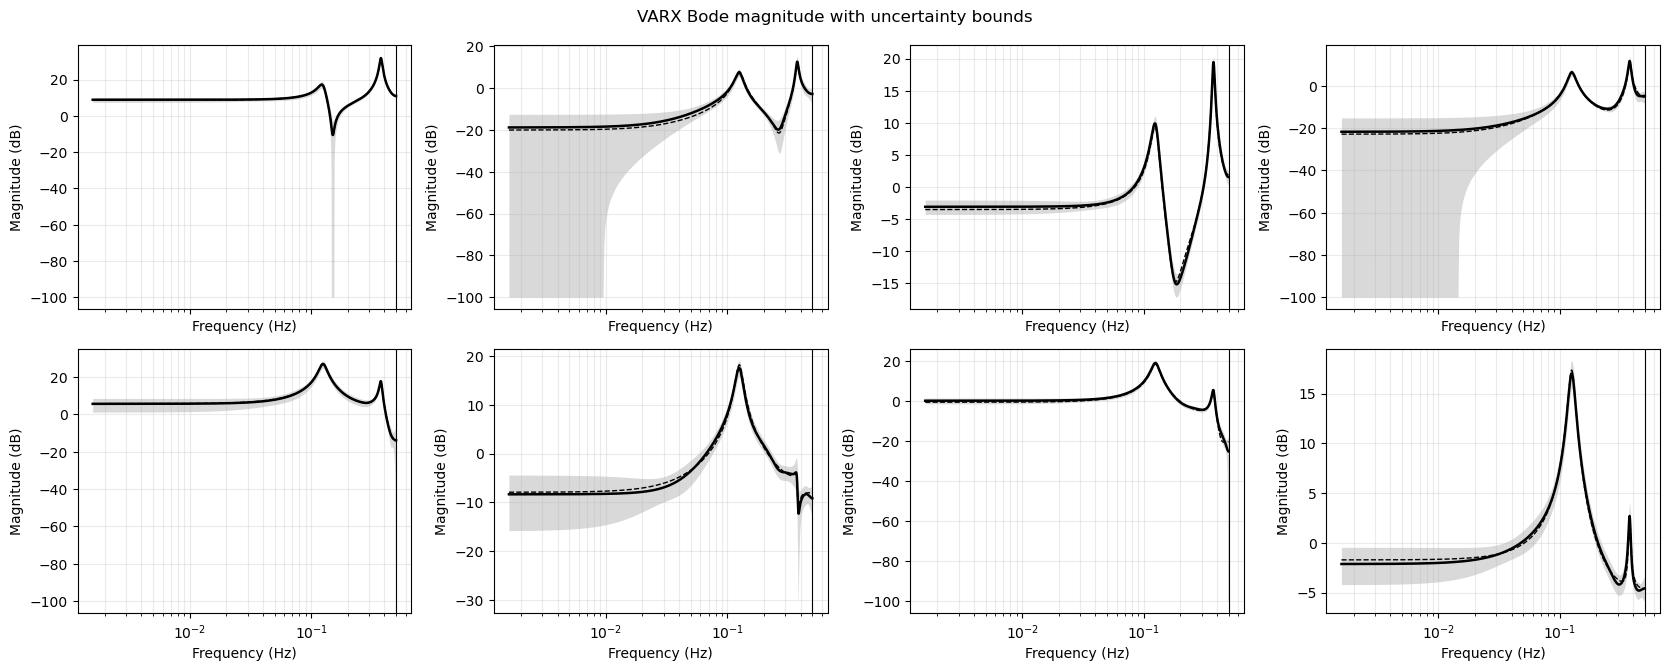

In [10]:
plt.figure(figsize=(10, 7))
dbodemagsd(g_varx, cov_g_varx, 2.8, w, 1.0, g_real)
plt.suptitle("VARX Bode magnitude with uncertainty bounds")
plt.tight_layout()

## PBSIDopt Identification Results
Run the notebook uncertainty pipeline for the PBSIDopt stage.

In [4]:
plt.figure(figsize=(10, 7))
dbodemagsd(g_abcdk, cov_g_abcdk, 2.8, w, 1.0, g_real)
plt.suptitle("PBSIDopt Bode magnitude with uncertainty bounds")
plt.tight_layout()

[ex06-uncertainty]
Uncertainty run: S size=(20,), eig count=4
VARX FRD shape=(2, 4, 300), cov shape=(2, 4, 300, 2, 2)
ABCDK FRD shape=(2, 4, 300), cov shape=(2, 4, 300, 2, 2)
Eigen covariance shape=(8, 8)


In [ ]:
plt.figure(figsize=(10, 7))
dnyquistsd(g_abcdk, cov_g_abcdk, 2.8, g_real)
plt.suptitle("PBSIDopt Nyquist diagram with uncertainty bounds")
plt.tight_layout()

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
deigensd(e_abcdk, cov_e_abcdk, 2.8, np.linalg.eigvals(a), ax=ax)
ax.set_title("PBSIDopt eigenvalues with covariance bounds")
fig.tight_layout()